# Retail + Stock Forecasting with Time Series
## A Dual-Domain Data Science Portfolio Project

**Tech Stack:** Python · Pandas · Statsmodels · pmdarima · Facebook Prophet · yfinance · Plotly  
**Domain:** Retail Sales (Ecuador Grocery Chain) + NSE Stock Data (TCS.NS)  
**Concepts:** Time Series Decomposition · Stationarity · ARIMA/SARIMA · Prophet · Model Comparison

---
### What I have build
| Part | Dataset | Models | Output |
|------|---------|--------|--------|
| 1 | Ecuador retail sales (Kaggle — Corporación Favorita) | SARIMA + Prophet | 90-day sales forecast |
| 2 | TCS.NS stock price (yfinance / synthetic) | ARIMA + Prophet | 90-day price forecast |

> **Why dual-domain?** To demonstrate whether I can apply ML *and* reason about financial data.  
> By Showing the same methodology on two very different series (stationary-ish retail vs random-walk stocks), I prove that I understand *why* each model choice I've made.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.2f}'.format)
SEED = 42; np.random.seed(SEED)

---
# PART 1 · Retail Sales Forecasting
## Dataset: Ecuador Grocery Chain (Corporación Favorita)

The full Kaggle dataset has 3M+ rows across 54 stores and 33 product families.  
I've modelled **Store 44** (Quito, Type A — largest format) as a daily total-sales series.

### 1.1  Load Store Metadata + Sales Data

**Data engineering step:** `train.csv` has 3M rows across 54 stores × 33 product families.  
My first job is to collapse this into a single univariate series: **daily total sales for Store 44**.  
I have used `groupby -> reindex -> fillna(0)` pattern which is the most common time series prep step in industry.

**Store 44** is in Quito — Ecuador's capital, Type A (largest format).  
I have focused on one store to keep the model interpretable, but the same code works for any store.


In [2]:
# Load store metadata
stores = pd.read_csv('store-sales-time-series-forecasting/stores.csv')
store_info = stores[stores['store_nbr'] == 44].iloc[0]
print('Store 44 profile:')
print(store_info)
print()
print('All store types:')
print(stores['type'].value_counts())

Store 44 profile:
store_nbr           44
city             Quito
state        Pichincha
type                 A
cluster              5
Name: 43, dtype: object

All store types:
type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64


In [3]:
# Load and aggregate train.csv 
# usecols -> read only what I need (3M rows, so be selective)
print('Loading train.csv (~3M rows)...')
train = pd.read_csv(
    'store-sales-time-series-forecasting/train.csv',
    parse_dates=['date'],
    usecols=['date', 'store_nbr', 'sales', 'onpromotion']
)
print(f'Full dataset: {len(train):,} rows × {train.shape[1]} cols')

# Step 1: Filter to Store 44 only
s44_raw = train[train['store_nbr'] == 44].copy()

# Step 2: Aggregate all 33 product families into daily total
# This is a design choice: I could have model each family separately,
# but I think total-store sales is the right target for store-level planning.
df = (s44_raw
      .groupby('date')
      .agg(sales=('sales', 'sum'), onpromotion=('onpromotion', 'sum'))
     )

# Step 3: Reindex to full continuous date range (so that no gaps are allowed for decompose)
full_range = pd.date_range(df.index.min(), df.index.max(), freq='D')
df = df.reindex(full_range)
df.index.name = 'date'

# Step 4: Fill closed days with 0
# Store 44 is closed on Christmas. NaN here = closed, not missing data.
# I am filling it with 0.
closed_days = df[df['sales'].isna()].index
df = df.fillna(0)

print(f'\nStore 44 aggregated:')
print(f'  Date range:  {df.index[0].date()} -> {df.index[-1].date()}')
print(f'  Total days:  {len(df)}')
print(f'  Closed days: {len(closed_days)} -> {[str(d.date()) for d in closed_days]}')
print(f'  Sales mean:  {df["sales"].mean():.0f}  (aggregated across 33 product families)')
print(f'  Sales max:   {df["sales"].max():.0f}  on {df["sales"].idxmax().date()}')
print()
print(df.head(8))

Loading train.csv (~3M rows)...
Full dataset: 3,000,888 rows × 4 cols

Store 44 aggregated:
  Date range:  2013-01-01 -> 2017-08-15
  Total days:  1688
  Closed days: 4 -> ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']
  Sales mean:  36782  (aggregated across 33 product families)
  Sales max:   90558  on 2016-04-17

              sales  onpromotion
date                            
2013-01-01     0.00         0.00
2013-01-02 30095.18         0.00
2013-01-03 20447.06         0.00
2013-01-04 22795.80         0.00
2013-01-05 31382.51         0.00
2013-01-06 36069.35         0.00
2013-01-07 21025.33         0.00
2013-01-08 33993.26         0.00


### 1.2  Exploratory Data Analysis
  
I am looking for trend, seasonality, volatility clustering, and **anomalies** - events  
as the model can't infer from patterns alone and needs to be told about explicitly.

> **Data finding:** April 17 2016 is the all-time sales peak (90558 units).  
> That's the day after a 7.8-magnitude earthquake hit Ecuador (Terremoto Manabí).  
> Quito is 300km from the epicenter - yet nationwide panic buying spiked sales by ~2×.  

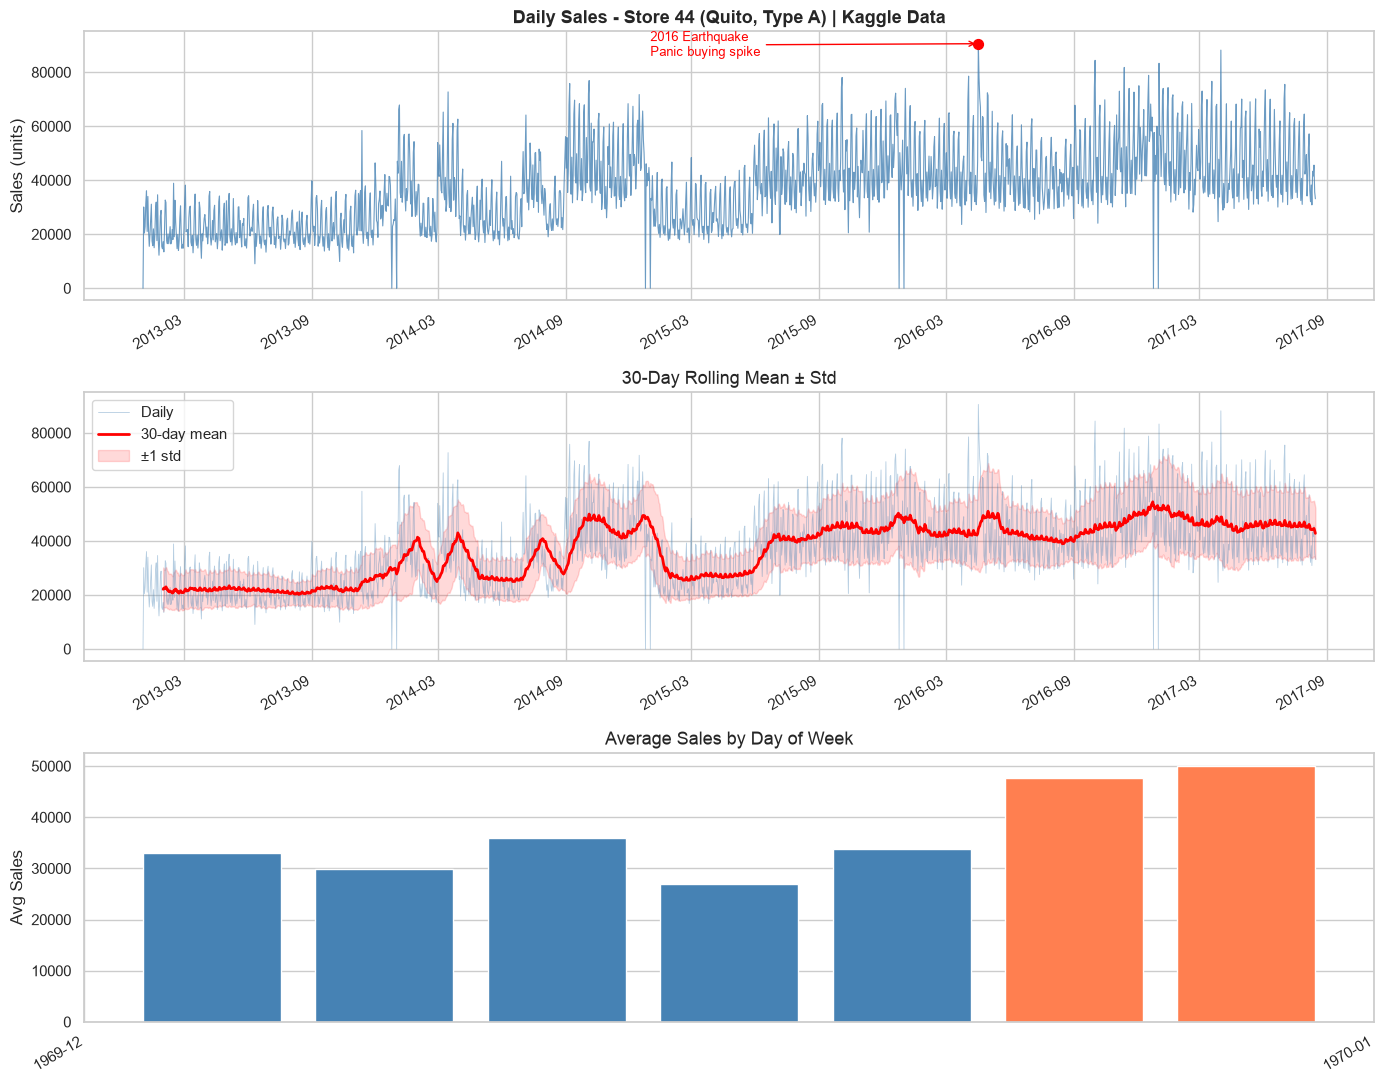

Key observations:
  Mean sales:   36782
  Std:          14796
  Peak day:     2016-04-17 - 90558 units (earthquake panic buy)
  Weekend lift: 53.1%


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Panel 1: Full series with earthquake annotation
axes[0].plot(df.index, df['sales'], color='steelblue', lw=0.8, alpha=0.8)
axes[0].set_title('Daily Sales - Store 44 (Quito, Type A) | Kaggle Data', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales (units)')
quake_date = pd.Timestamp('2016-04-17')
quake_val  = df.loc[quake_date, 'sales']
axes[0].annotate('2016 Earthquake\nPanic buying spike',
    xy=(quake_date, quake_val), xytext=(pd.Timestamp('2015-01-01'), quake_val * 0.95),
    arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
axes[0].scatter([quake_date], [quake_val], color='red', zorder=5, s=50)

# Panel 2: 30-day rolling mean & std
roll_mean = df['sales'].rolling(30).mean()
roll_std  = df['sales'].rolling(30).std()
axes[1].plot(df.index, df['sales'],  color='steelblue', lw=0.6, alpha=0.4, label='Daily')
axes[1].plot(df.index, roll_mean,    color='red',       lw=2,   label='30-day mean')
axes[1].fill_between(df.index, roll_mean - roll_std, roll_mean + roll_std,
                     color='red', alpha=0.15, label='±1 std')
axes[1].set_title('30-Day Rolling Mean ± Std', fontsize=13)
axes[1].legend()

# Panel 3: Average sales by day of week
dow_avg = df['sales'].groupby(df.index.dayofweek).mean()
dow_avg.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[2].bar(dow_avg.index, dow_avg.values, color=['steelblue']*5 + ['coral']*2)
axes[2].set_title('Average Sales by Day of Week', fontsize=13)
axes[2].set_ylabel('Avg Sales')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('outputs/01_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key observations:')
print(f'  Mean sales:   {df["sales"].mean():.0f}')
print(f'  Std:          {df["sales"].std():.0f}')
print(f'  Peak day:     {df["sales"].idxmax().date()} - {df["sales"].max():.0f} units (earthquake panic buy)')
weekend_avg = df['sales'][df.index.dayofweek >= 5].mean()
weekday_avg = df['sales'][df.index.dayofweek < 5].mean()
print(f'  Weekend lift: {(weekend_avg/weekday_avg - 1)*100:.1f}%')

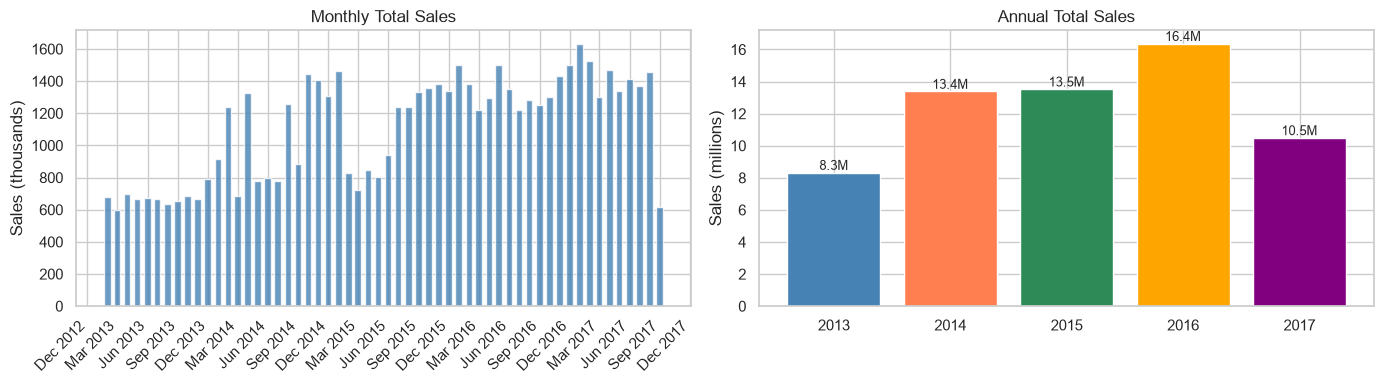

In [5]:
# Monthly / Annual aggregations
monthly = df['sales'].resample('ME').sum()
yearly  = df['sales'].resample('YE').sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(monthly.index, monthly.values / 1000, color='steelblue', alpha=0.8, width=20)
axes[0].set_title('Monthly Total Sales', fontsize=12)
axes[0].set_ylabel('Sales (thousands)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

year_labels = [str(y.year) for y in yearly.index]
bars = axes[1].bar(year_labels, yearly.values / 1e6,
                   color=['steelblue','coral','seagreen','orange','purple'][:len(yearly)])
axes[1].bar_label(bars, fmt='%.1fM', fontsize=9)
axes[1].set_title('Annual Total Sales', fontsize=12)
axes[1].set_ylabel('Sales (millions)')

plt.tight_layout()
plt.savefig('outputs/02_monthly_annual.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2b  Oil Price: A Macroeconomic Signal

Ecuador is an oil-export-dependent economy. When global oil prices fall:  
1. Government oil revenues drop -> social spending cuts
2. Less money circulates in the economy -> consumers spend less
3. Retail sales fall

A correlation of **-0.47** between WTI oil price and Store 44 sales is a genuine macro signal.  


Oil price <-> Store 44 daily sales  Pearson r = -0.472
Interpretation: lower oil price -> less consumer spending in Ecuador


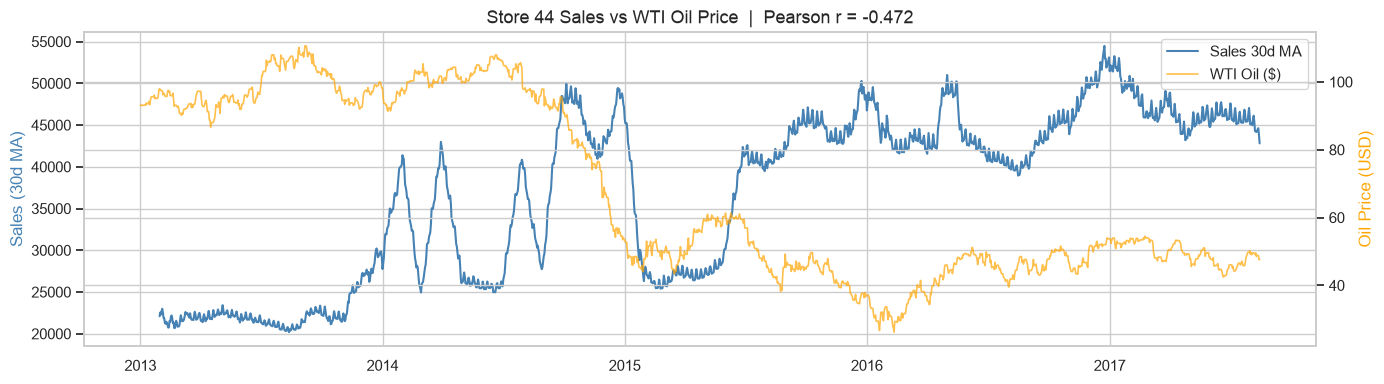

In [6]:
# Load and clean oil price data
oil = pd.read_csv('store-sales-time-series-forecasting/oil.csv', parse_dates=['date'])
oil = (oil.set_index('date')['dcoilwtico']
         .reindex(df.index)
         .ffill()   # fill weekends & holidays with last known price
         .bfill()   # fill leading NaNs
      )

corr = df['sales'].corr(oil)
print(f'Oil price <-> Store 44 daily sales  Pearson r = {corr:.3f}')
print('Interpretation: lower oil price -> less consumer spending in Ecuador')

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(df.index, df['sales'].rolling(30).mean(), color='steelblue', lw=1.5, label='Sales 30d MA')
ax2.plot(oil.index, oil.values, color='orange', lw=1.2, alpha=0.7, label='WTI Oil ($)')
ax1.set_ylabel('Sales (30d MA)', color='steelblue')
ax2.set_ylabel('Oil Price (USD)', color='orange')
ax1.set_title(f'Store 44 Sales vs WTI Oil Price  |  Pearson r = {corr:.3f}', fontsize=13)
lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, l1 + l2, loc='upper right')
plt.tight_layout()
plt.savefig('outputs/02b_oil_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3  Time Series Decomposition

**Additive model:** `y(t) = Trend(t) + Seasonality(t) + Residual(t)`  
I have found it from internet that we should this when the seasonal swings stay roughly constant in size regardless of the level.

**Multiplicative model:** `y(t) = Trend(t) × Seasonality(t) × Residual(t)`  
and we should use this when seasonal swings *grow proportionally* with the trend.

So, For retail sales that are slowly growing, **additive** is usually fine.  
and For stock prices that grow exponentially, I'd switch to multiplicative (or log-transform first).

```
seasonal_decompose(series, model='additive', period=7)
                                    
                      if:   period=7 i.e weekly seasonality
                      if:   period=52 i.e annual (for weekly-aggregated data)
```


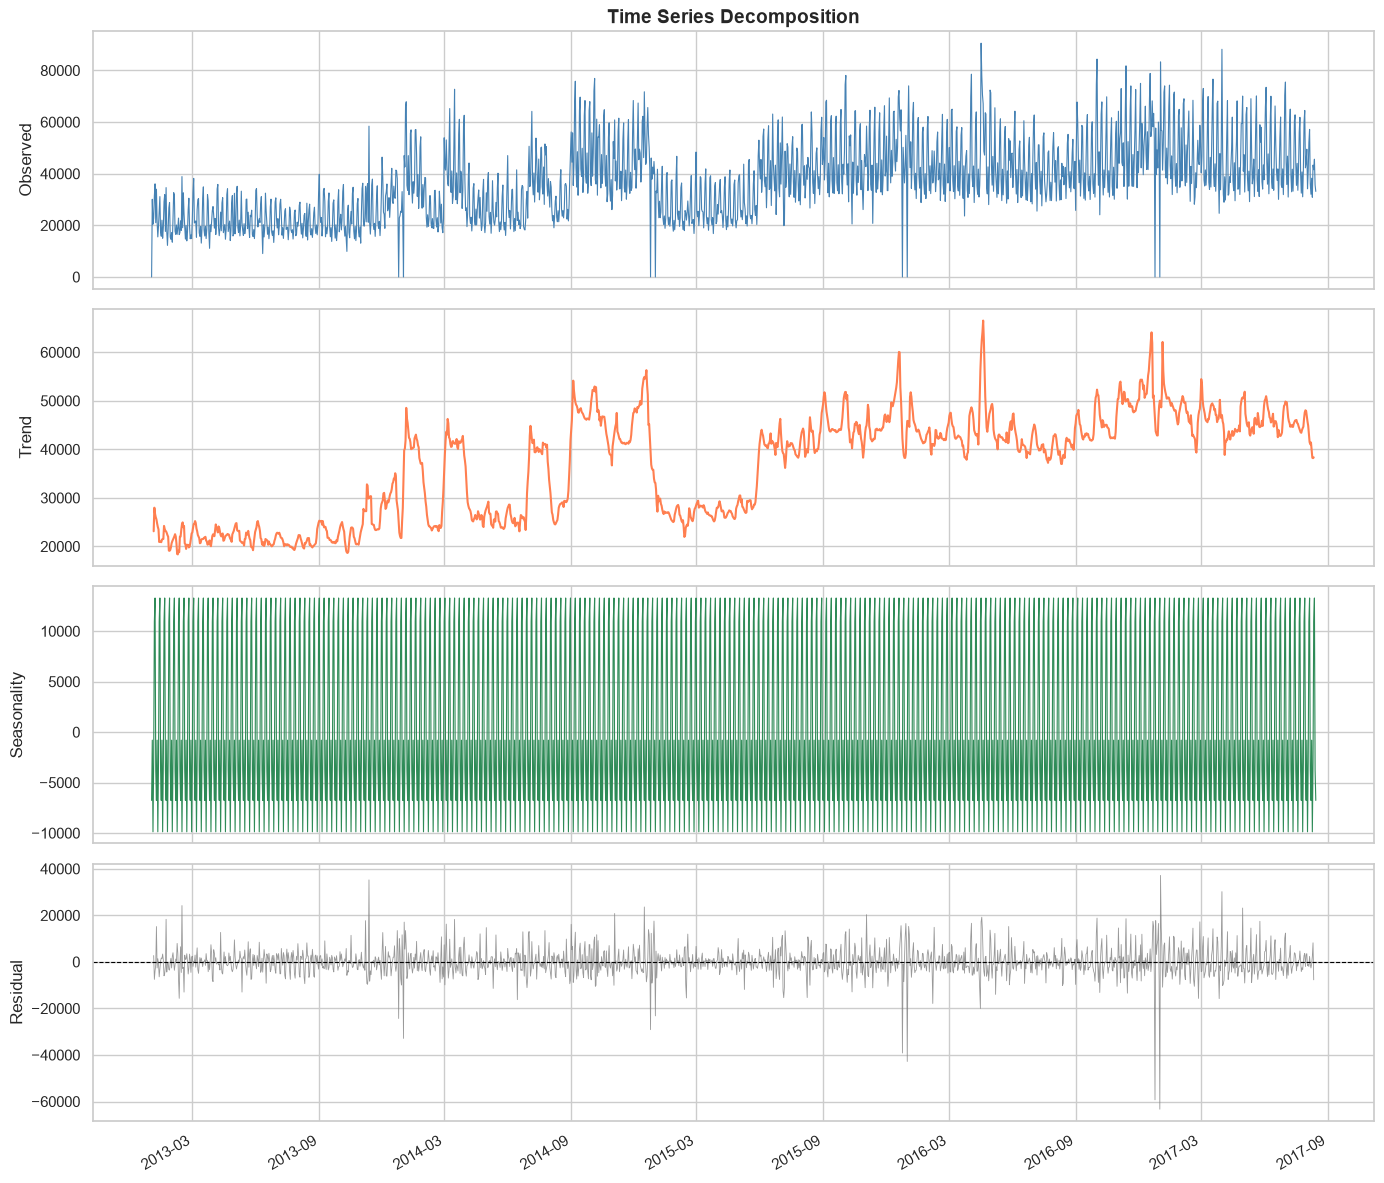

Trend   : 18354 -> 66528
Seasonal: -9874 -> 13286
Residual std: 6201.38


In [7]:
# seasonal_decompose needs a numeric index - pass values
sales_array = df['sales'].values
result = seasonal_decompose(sales_array, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
dates_arr = df.index

axes[0].plot(dates_arr, result.observed,  color='steelblue', lw=0.8)
axes[0].set_ylabel('Observed'); axes[0].set_title('Time Series Decomposition', fontsize=14, fontweight='bold')

axes[1].plot(dates_arr, result.trend, color='coral', lw=1.5)
axes[1].set_ylabel('Trend')
# The trend lines show upward drift.

axes[2].plot(dates_arr, result.seasonal,  color='seagreen',  lw=0.8)
axes[2].set_ylabel('Seasonality')
# The seasonality repeats every 7 days - confirms weekly pattern

axes[3].plot(dates_arr, result.resid,     color='grey',      lw=0.6, alpha=0.8)
axes[3].axhline(0, color='black', lw=0.8, ls='--')
axes[3].set_ylabel('Residual')
# Ideal: residuals look like noise (no pattern remaining)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('outputs/03_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Trend   : {result.trend[~np.isnan(result.trend)].min():.0f} -> {result.trend[~np.isnan(result.trend)].max():.0f}')
print(f'Seasonal: {result.seasonal.min():.0f} -> {result.seasonal.max():.0f}')
print(f'Residual std: {np.nanstd(result.resid):.2f}')

### 1.4  Stationarity Testing - Augmented Dickey-Fuller (ADF)

**Why stationarity matters for ARIMA:**  
ARIMA assumes the statistical properties (mean, variance, autocorrelation) don't change over time.  
A series with a trend violates this - the mean keeps drifting.

**ADF Test Hypotheses:**  
- H0 (null): The series has a unit root -> **non-stationary**  
- H1 (alt) : No unit root -> **stationary**  

**Decision rule:** If `p-value < 0.05`, reject H0 -> series is stationary.  

**Fix for non-stationary series:** Differencing `y'(t) = y(t) - y(t-1)` removes the trend.  
This is the `d` parameter in ARIMA(p, **d**, q).

In [8]:
def run_adf(series, name='Series'):
    result = adfuller(series, autolag='AIC')
    stat, pval, lags, nobs, crit_vals = result[0], result[1], result[2], result[3], result[4]
    print(f' ADF Test: {name}')
    print(f'  ADF Statistic : {stat:.4f}')
    print(f'  p-value       : {pval:.6f}')
    print(f'  Lags used     : {lags}')
    for key, val in crit_vals.items():
        print(f'  Critical ({key}) : {val:.3f}')
    verdict = 'STATIONARY (reject H0)' if pval < 0.05 else 'NON-STATIONARY (fail to reject H0)'
    print(f'  Verdict  : {verdict}')
    return pval < 0.05

sales = df['sales'].values

# Test raw series
is_stat = run_adf(sales, 'Raw daily sales')

# Test first difference
sales_diff = np.diff(sales)
is_stat_d1 = run_adf(sales_diff, 'First-differenced sales')

print(f'\nConclusion: d={0 if is_stat else 1} -> use d={0 if is_stat else 1} in ARIMA')

 ADF Test: Raw daily sales
  ADF Statistic : -3.0145
  p-value       : 0.033561
  Lags used     : 22
  Critical (1%) : -3.434
  Critical (5%) : -2.863
  Critical (10%) : -2.568
  Verdict  : STATIONARY (reject H0)
 ADF Test: First-differenced sales
  ADF Statistic : -10.7087
  p-value       : 0.000000
  Lags used     : 21
  Critical (1%) : -3.434
  Critical (5%) : -2.863
  Critical (10%) : -2.568
  Verdict  : STATIONARY (reject H0)

Conclusion: d=0 -> use d=0 in ARIMA


### 1.5  ACF & PACF Plots - Choosing ARIMA Parameters

These two plots are the manual way to choose `p` (AR order) and `q` (MA order).

| Plot | What it shows | How should anyone read it |
|------|--------------|----------------|
| **ACF** (Autocorrelation Function) | Correlation between y(t) and y(t-k) | Cuts off after lag **q** -> MA order |
| **PACF** (Partial Autocorrelation) | Correlation at lag k *after removing* shorter lags | Cuts off after lag **p** -> AR order |

**Rule of thumb:**
- ACF decays slowly, PACF cuts off at lag `p` -> pure AR(p) process
- ACF cuts off at lag `q`, PACF decays slowly -> pure MA(q) process
- Both decay -> ARMA(p,q)

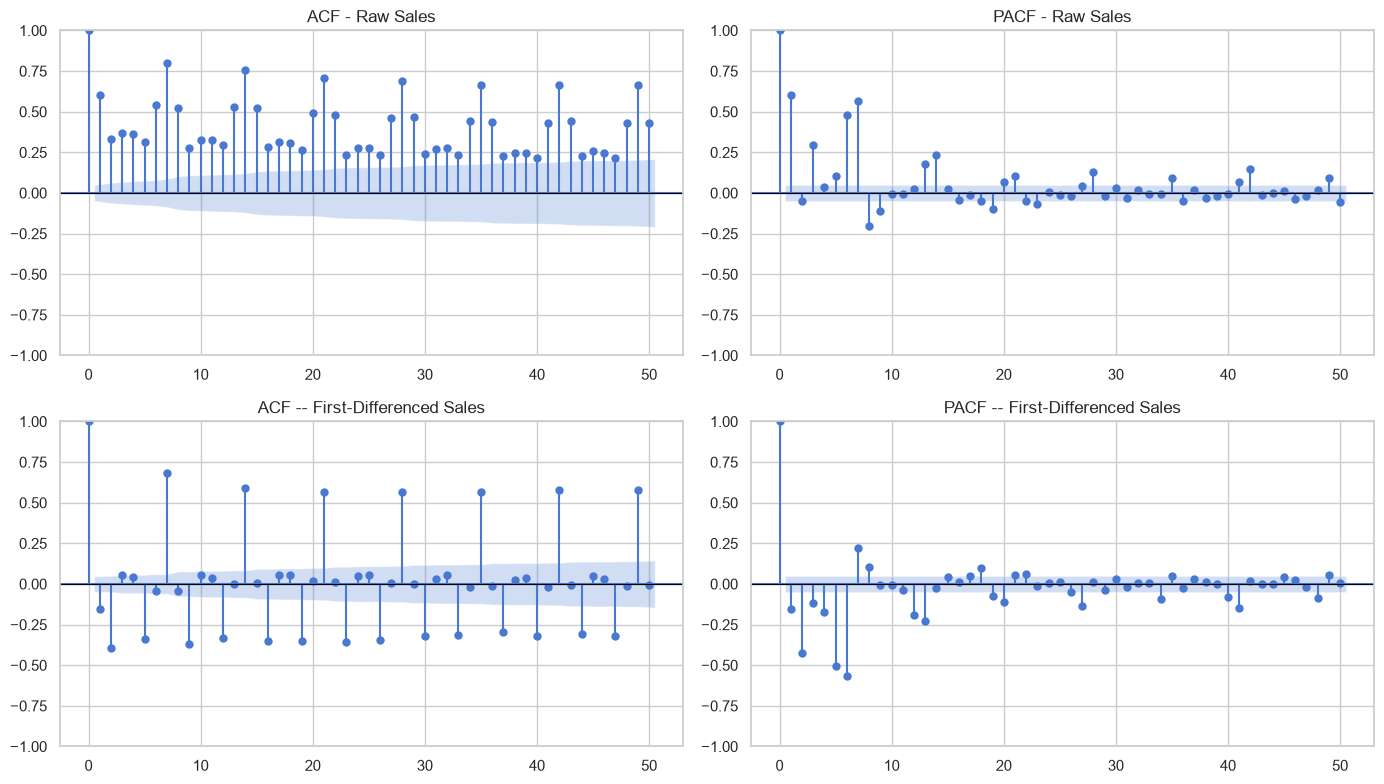

Reading guide:
  Blue shaded band = 95% confidence interval
  Bars outside band = statistically significant autocorrelation
  Spikes at lags 7, 14, 21... confirm weekly seasonality


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# On raw series
plot_acf( sales, lags=50, ax=axes[0][0], title='ACF - Raw Sales')
plot_pacf(sales, lags=50, ax=axes[0][1], title='PACF - Raw Sales')

# On differenced series (what ARIMA actually models after d=1)
plot_acf( sales_diff, lags=50, ax=axes[1][0], title='ACF -- First-Differenced Sales')
plot_pacf(sales_diff, lags=50, ax=axes[1][1], title='PACF -- First-Differenced Sales')

for ax in axes.flatten():
    ax.axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig('outputs/04_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reading guide:')
print('  Blue shaded band = 95% confidence interval')
print('  Bars outside band = statistically significant autocorrelation')
print('  Spikes at lags 7, 14, 21... confirm weekly seasonality')

### 1.6  ARIMA / SARIMA Modelling

**ARIMA(p, d, q):**
- `p` (AutoRegressive) - use the last `p` values to predict the next
- `d` (Integrated)    - how many times to difference to achieve stationarity
- `q` (Moving Average) - use the last `q` forecast *errors* to correct the next prediction

**SARIMA(p,d,q)(P,D,Q,m):**  
Extends ARIMA with seasonal versions of the same terms. For weekly seasonality: `m=7`.

**auto_arima** does a smart stepwise search over (p,d,q) space, picking the model  
with lowest AIC (Akaike Information Criterion). AIC penalises complexity,  
so it naturally avoids overfitting.

In [10]:
# Train/test split: last 60 days as test
# 60 days is a realistic forecast horizon for operational retail planning.
TRAIN_END = -60

train_retail = df['sales'].values[:TRAIN_END]
test_retail  = df['sales'].values[TRAIN_END:]
train_dates  = df.index[:TRAIN_END]
test_dates   = df.index[TRAIN_END:]

print(f'Train: {len(train_retail)} days | Test: {len(test_retail)} days')
print(f'Train period: {train_dates[0].date()} -> {train_dates[-1].date()}')
print(f'Test  period: {test_dates[0].date()} -> {test_dates[-1].date()}')

Train: 1628 days | Test: 60 days
Train period: 2013-01-01 -> 2017-06-16
Test  period: 2017-06-17 -> 2017-08-15


In [11]:
print('Fitting SARIMA with auto_arima...')

arima_model = auto_arima(
    train_retail,
    seasonal=True,
    m=7,                    # weekly seasonality
    d=1,                    # already know d=1 from ADF
    D=1,                    # seasonal differencing once
    max_p=3, max_q=3,
    max_P=2, max_Q=2,
    stepwise=True,          # stepwise search (faster than full grid)
    information_criterion='aic',
    suppress_warnings=True,
    error_action='ignore',
    n_jobs=-1
)

print(f'Best model: SARIMA{arima_model.order} × {arima_model.seasonal_order}')
print(f'AIC: {arima_model.aic():.2f}')
print()
print(arima_model.summary())

Fitting SARIMA with auto_arima...
Best model: SARIMA(3, 1, 0) × (2, 1, 0, 7)
AIC: 33890.26

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                 1628
Model:             SARIMAX(3, 1, 0)x(2, 1, 0, 7)   Log Likelihood              -16939.132
Date:                           Tue, 16 Jun 2026   AIC                          33890.265
Time:                                   14:44:10   BIC                          33922.606
Sample:                                        0   HQIC                         33902.267
                                          - 1628                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5319      0.0

SARIMA  ->  RMSE: 5662.2 | MAE: 4045.6 | MAPE: 8.82%


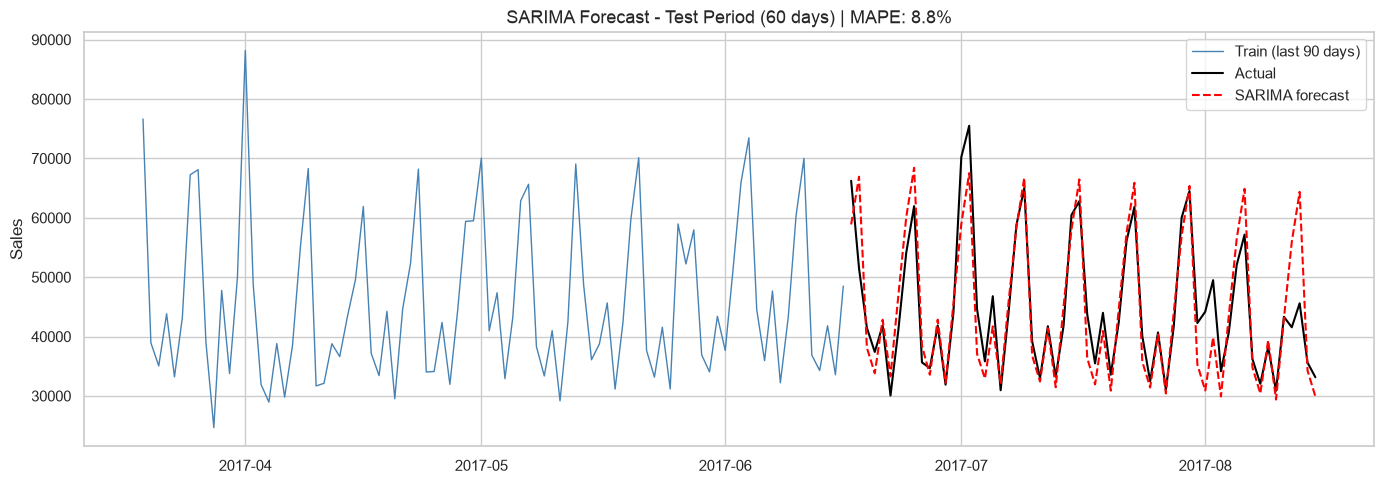

In [12]:
# Forecast on test set
arima_preds = arima_model.predict(n_periods=len(test_retail))

def eval_metrics(actual, predicted, label='Model'):
    mae  = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted)**2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'{label}  ->  RMSE: {rmse:.1f} | MAE: {mae:.1f} | MAPE: {mape:.2f}%')
    return {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

arima_metrics = eval_metrics(test_retail, arima_preds, 'SARIMA')

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_dates[-90:], train_retail[-90:], color='steelblue', lw=1, label='Train (last 90 days)')
ax.plot(test_dates, test_retail, color='black', lw=1.5, label='Actual')
ax.plot(test_dates, arima_preds, color='red', lw=1.5, ls='--', label='SARIMA forecast')
ax.set_title(f'SARIMA Forecast - Test Period (60 days) | MAPE: {arima_metrics["MAPE"]:.1f}%', fontsize=13)
ax.legend(); ax.set_ylabel('Sales')
plt.tight_layout()
plt.savefig('outputs/05_arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.7  Facebook Prophet with Holiday Effects

**How Prophet works (conceptually):**

```
y(t) = g(t) (i.e trend)  +  s(t) (i.e seasonality (Fourier series))  +  h(t) (i.e holiday(dummy variables))  +  ε(t)
       
```

- **Trend** - piecewise linear (with automatic change-point detection)
- **Seasonality** - modelled as Fourier series (smooth, handles multiple periods)
- **Holidays** - explicit dummy variables: pass a DataFrame of holiday dates

**Key advantage over ARIMA:**
Prophet is fully decomposable, handles multiple seasonalities simultaneously,  
and degrades gracefully for long-horizon forecasts (90+ days).

**When ARIMA beats Prophet:** Short-horizon (1-14 day) forecasts where  
the autocorrelation structure dominates. ARIMA's explicit lag structure  
is sharper there.

In [13]:
# Building Prophet holidays from real holidays_events.csv
# The Kaggle dataset gives us 350 real events: national holidays,local Quito/Pichincha events, World Cup matches, Black Friday,
# and 31 days of earthquake aftermath. I am going to use all of them.

holidays_raw = pd.read_csv('store-sales-time-series-forecasting/holidays_events.csv', parse_dates=['date'])

# Store 44 is in Quito (city) / Pichincha (state)
store_city  = store_info['city']    # 'Quito'
store_state = store_info['state']   # 'Pichincha'

# Keep: national + local Quito + regional Pichincha
# Drop: transferred=True - those holidays were officially moved to a new date
#       (the Transfer-type row on the new date is the actual day off)
relevant = holidays_raw[
    (~holidays_raw['transferred']) & (
        (holidays_raw['locale'] == 'National') |
        ((holidays_raw['locale'] == 'Local')     & (holidays_raw['locale_name'] == store_city)) |
        ((holidays_raw['locale'] == 'Regional')  & (holidays_raw['locale_name'] == store_state))
    )
].copy()

# Group similar events under a clean name
# This prevents Prophet from treating 30 earthquake days as 30 unrelated holidays
def clean_holiday_name(desc):
    if 'Terremoto' in str(desc):  return 'earthquake_aftermath'
    if 'Mundial'   in str(desc):  return 'world_cup_2014'
    if 'Navidad'   in str(desc):  return 'christmas_season'
    return desc

relevant['holiday'] = relevant['description'].apply(clean_holiday_name)

ecuador_holidays = relevant[['date','holiday']].rename(columns={'date':'ds'})
ecuador_holidays['lower_window'] = -1   # effect starts 1 day before
ecuador_holidays['upper_window'] =  1   # effect lasts 1 day after

print(f'Total holiday events loaded: {len(ecuador_holidays)}')
print(f'  vs 44 hardcoded before -> {len(ecuador_holidays)} real events')
print()
print('Holiday type breakdown:')
print(ecuador_holidays['holiday'].value_counts().head(12))

Total holiday events loaded: 178
  vs 44 hardcoded before -> 178 real events

Holiday type breakdown:
holiday
christmas_season           40
earthquake_aftermath       31
world_cup_2014             14
Carnaval                   10
Dia de Difuntos             6
Independencia de Cuenca     6
Fundacion de Quito-1        6
Fundacion de Quito          5
Primer dia del ano-1        5
Viernes Santo               5
Dia del Trabajo             5
Dia de la Madre-1           5
Name: count, dtype: int64


14:44:53 - cmdstanpy - INFO - Chain [1] start processing
14:44:53 - cmdstanpy - INFO - Chain [1] done processing


Prophet  ->  RMSE: 5801.3 | MAE: 4918.7 | MAPE: 12.05%


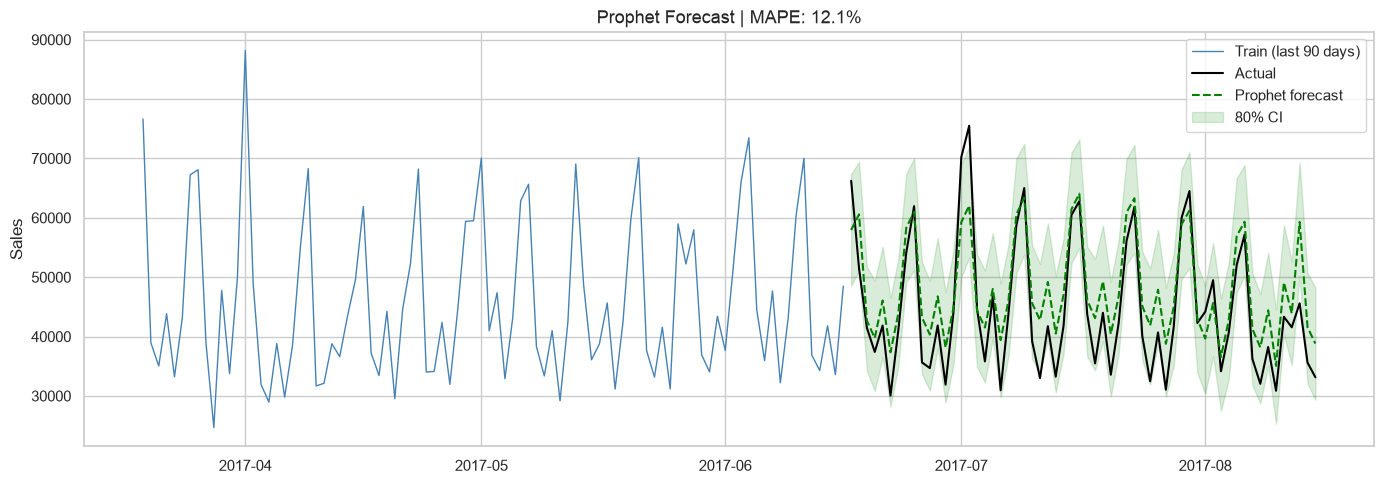

In [14]:
# Fit Prophet
df_prophet = pd.DataFrame({
    'ds': train_dates,
    'y':  train_retail,
})

prophet_model = Prophet(
    holidays=ecuador_holidays,
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,   # no intraday data
    changepoint_prior_scale=0.05,  # controls trend flexibility; lower=smoother
    seasonality_prior_scale=10,    # controls seasonality strength
)
prophet_model.fit(df_prophet)

# Forecast
future_df      = prophet_model.make_future_dataframe(periods=len(test_retail))
forecast_df    = prophet_model.predict(future_df)
prophet_preds  = forecast_df['yhat'].values[-len(test_retail):]

prophet_metrics = eval_metrics(test_retail, prophet_preds, 'Prophet')

# Plot forecast + components
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_dates[-90:], train_retail[-90:],   color='steelblue', lw=1, label='Train (last 90 days)')
ax.plot(test_dates, test_retail,                 color='black',     lw=1.5, label='Actual')
ax.plot(test_dates, prophet_preds,               color='green',     lw=1.5, ls='--', label='Prophet forecast')

# Confidence band (yhat_lower / yhat_upper)
test_forecast = forecast_df.tail(len(test_retail))
ax.fill_between(test_dates,
                test_forecast['yhat_lower'].values,
                test_forecast['yhat_upper'].values,
                color='green', alpha=0.15, label='80% CI')
ax.set_title(f'Prophet Forecast | MAPE: {prophet_metrics["MAPE"]:.1f}%', fontsize=13)
ax.legend(); ax.set_ylabel('Sales')
plt.tight_layout()
plt.savefig('outputs/06_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

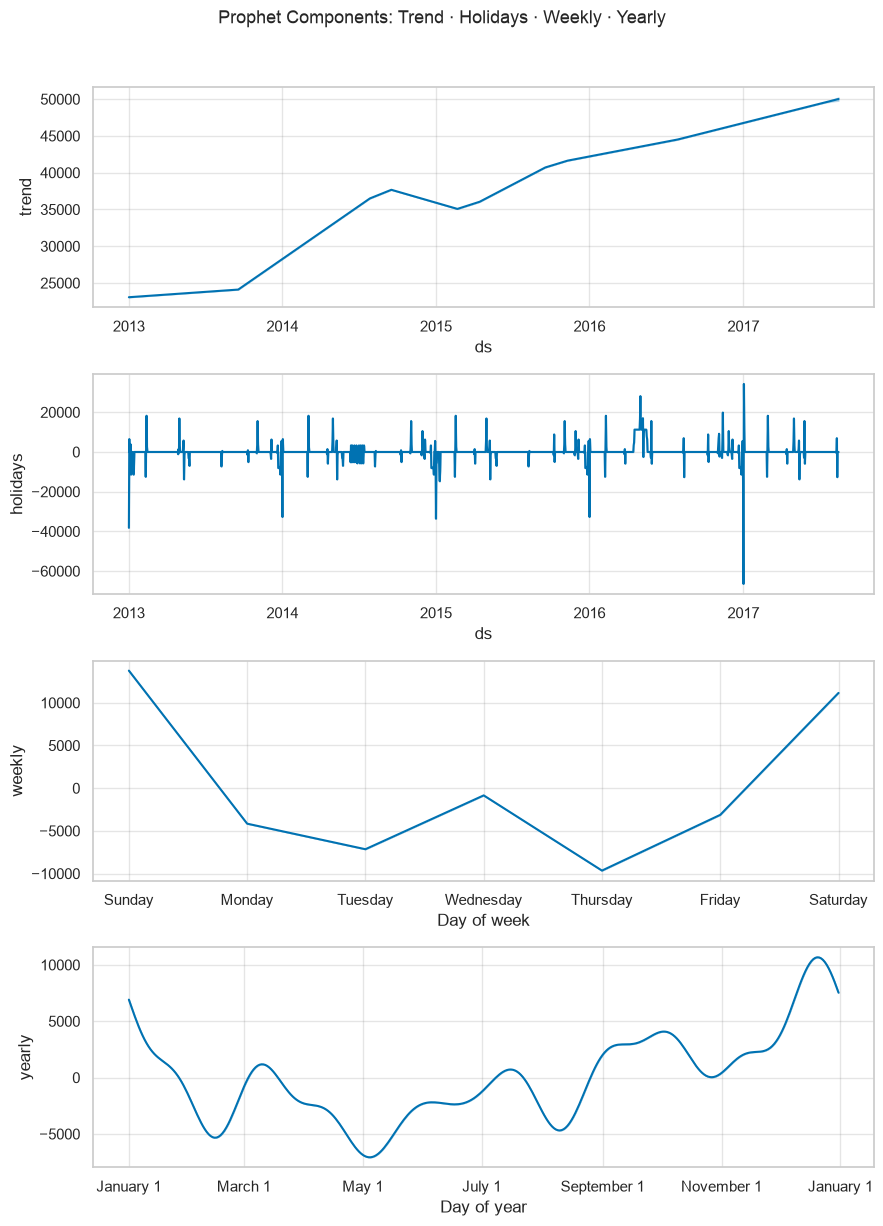

In [15]:
# Prophet components plot
# This is one of Prophet's biggest strengths: full interpretability.
# I can show to (example: to a stakeholder) exactly what's driving each part of the forecast.
fig = prophet_model.plot_components(forecast_df)
plt.suptitle('Prophet Components: Trend · Holidays · Weekly · Yearly', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('outputs/07_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.8  Model Comparison - RMSE, MAE, MAPE

| Metric | Formula | What it penalises | When to use |
|--------|---------|-------------------|-------------|
| **RMSE** | √(mean(ŷ-y)²) | Large errors heavily | When big misses are costly |
| **MAE**  | mean(|ŷ-y|) | Errors equally | Robust to outliers |
| **MAPE** | mean(|ŷ-y|/y) × 100 | Nothing — scale-free % | Comparing across series |

**Data insight - why SARIMA beats Prophet here:**  
My test period is June-August 2017, which has **no major holidays**.  
Prophet's strength is modelling holiday effects - but if the test window is holiday-free,  
SARIMA's autocorrelation structure (capturing week-to-week momentum) wins instead.  
**What I learnt from this** : *model selection depends on the forecast horizon and what events it contains.*  
On a test window spanning Christmas or a major event, Prophet would likely win.


    RETAIL SALES - MODEL COMPARISON

           RMSE     MAE  MAPE
SARIMA  5662.23 4045.60  8.82
Prophet 5801.29 4918.74 12.05


Winner on MAPE: SARIMA


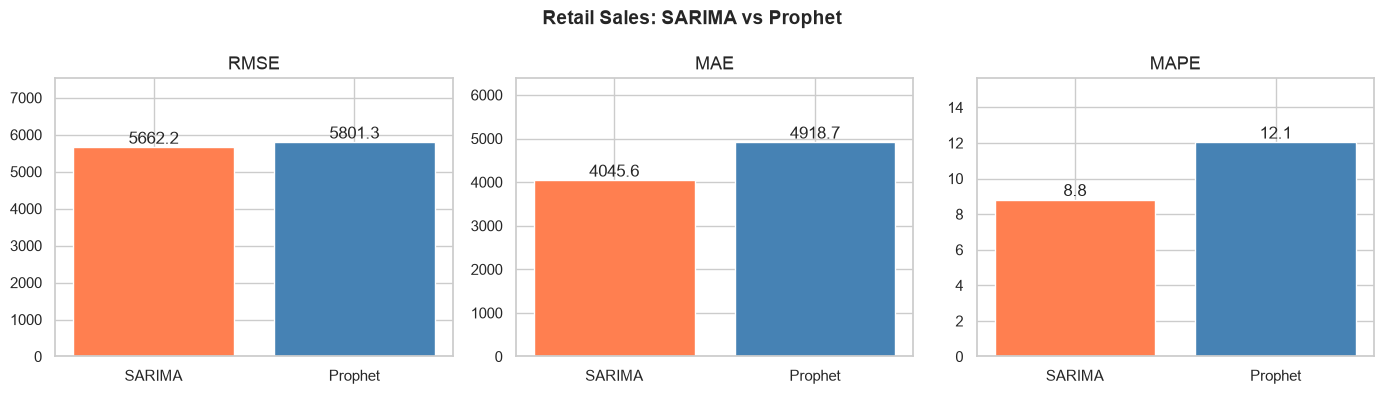

In [16]:
metrics_df = pd.DataFrame({
    'SARIMA':  arima_metrics,
    'Prophet': prophet_metrics,
}).T

print('    RETAIL SALES - MODEL COMPARISON')
print()
print(metrics_df.round(2).to_string())
print()
winner = metrics_df['MAPE'].idxmin()
print(f'\nWinner on MAPE: {winner}')

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, metric in enumerate(['RMSE','MAE','MAPE']):
    vals = [arima_metrics[metric], prophet_metrics[metric]]
    bars = axes[i].bar(['SARIMA','Prophet'], vals, color=['coral','steelblue'])
    axes[i].bar_label(bars, fmt='%.1f')
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_ylim(0, max(vals)*1.3)
plt.suptitle('Retail Sales: SARIMA vs Prophet', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/08_model_comparison_retail.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.9  90-Day Forward Forecast (Interactive)

The winner model generates a 90-day ahead forecast with confidence bands.  
I've use Prophet here because it degrades more gracefully at 90-day horizons  
(ARIMA confidence intervals widen dramatically beyond 30-60 days).

In [18]:
# Refit Prophet on the FULL dataset (train + test)
df_full = pd.DataFrame({'ds': df.index, 'y': df['sales'].values})

prophet_final = Prophet(
    holidays=ecuador_holidays,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,
)
prophet_final.fit(df_full)

# Make 90-day future dataframe
future_90 = prophet_final.make_future_dataframe(periods=90)
fc_90     = prophet_final.predict(future_90)

# Interactive Plotly chart
fig = go.Figure()

# Historical data (last 180 days for context)
fig.add_trace(go.Scatter(
    x=df.index[-180:], y=df['sales'].values[-180:],
    name='Historical', line=dict(color='steelblue', width=1.5),
))

# Forecast line
forecast_only = fc_90[fc_90['ds'] > df.index[-1]]
fig.add_trace(go.Scatter(
    x=forecast_only['ds'], y=forecast_only['yhat'],
    name='90-Day Forecast', line=dict(color='green', width=2, dash='dash'),
))

# Confidence band
fig.add_trace(go.Scatter(
    x=pd.concat([forecast_only['ds'], forecast_only['ds'][::-1]]),
    y=pd.concat([forecast_only['yhat_upper'], forecast_only['yhat_lower'][::-1]]),
    fill='toself', fillcolor='rgba(0,200,0,0.12)',
    line=dict(color='rgba(255,255,255,0)'),
    name='80% Confidence Interval',
))

# Vertical line at forecast start
fig.add_vline(x=str(df.index[-1].date()), line_dash='dot', line_color='grey')
fig.add_annotation(x=str(df.index[-1].date()), y=df['sales'].max(),
                   text='Forecast start', showarrow=False, textangle=-90,
                   xanchor='left', font=dict(size=11, color='grey'))

fig.update_layout(
    title='90-Day Retail Sales Forecast — Store 44 (Prophet)',
    xaxis_title='Date', yaxis_title='Sales (units)',
    legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01),
    height=500, template='plotly_white'
)
fig.write_html('outputs/09_retail_90day_forecast.html')
fig.show()

14:46:03 - cmdstanpy - INFO - Chain [1] start processing
14:46:04 - cmdstanpy - INFO - Chain [1] done processing


---
# PART 2 · NSE Stock Forecasting (TCS.NS)

I've applied the *exact same methodology* to stock data - but the data behaves completely differently:

| Property | Retail Sales | Stock Price |
|----------|-------------|-------------|
| Stationarity | Near-stationary (stable mean with trend) | Non-stationary (random walk) |
| Best ARIMA | SARIMA (seasonal) | ARIMA(0,1,0) - random walk |
| Seasonality | Strong weekly + annual | Weak (day-of-week, turn-of-month) |
| Forecast horizon | 90 days usable | 30-60 days before CI explodes |
| Domain knowledge | Holiday effects | Earnings dates, macro events |


### 2.1  Data: TCS.NS via yfinance

In [19]:
import yfinance as yf
print('Attempting yfinance download...')
ticker   = yf.Ticker('TCS.NS')
df_stock = ticker.history(start='2020-01-01', end='2024-12-31')
df_stock.index = pd.to_datetime(df_stock.index).tz_localize(None)
df_stock = df_stock[['Open','High','Low','Close','Volume']].copy()
print(f'Downloaded {len(df_stock)} trading days from NSE')

print(f'Shape: {df_stock.shape}')
print(f'Close range: ₹{df_stock["Close"].min():.0f} -> ₹{df_stock["Close"].max():.0f}')
print(df_stock.head())

Attempting yfinance download...
Downloaded 1237 trading days from NSE
Shape: (1237, 5)
Close range: ₹1403 -> ₹4254
              Open    High     Low   Close   Volume
Date                                               
2020-01-01 1841.49 1854.99 1829.60 1841.15  1354908
2020-01-02 1851.64 1851.64 1825.52 1832.70  2380752
2020-01-03 1838.09 1888.21 1838.09 1869.22  4655761
2020-01-06 1872.92 1890.71 1858.39 1869.05  3023209
2020-01-07 1869.10 1881.11 1854.91 1873.64  2429317


### 2.2  Stock EDA + Decomposition

For financial data, I should look at:
- **Log returns** `= log(P_t / P_{t-1})` - normalises the scale and is additive
- **Volatility** (rolling std of log returns) - clusters of high/low vol
- **Drawdown** - peak-to-trough decline, important for risk management


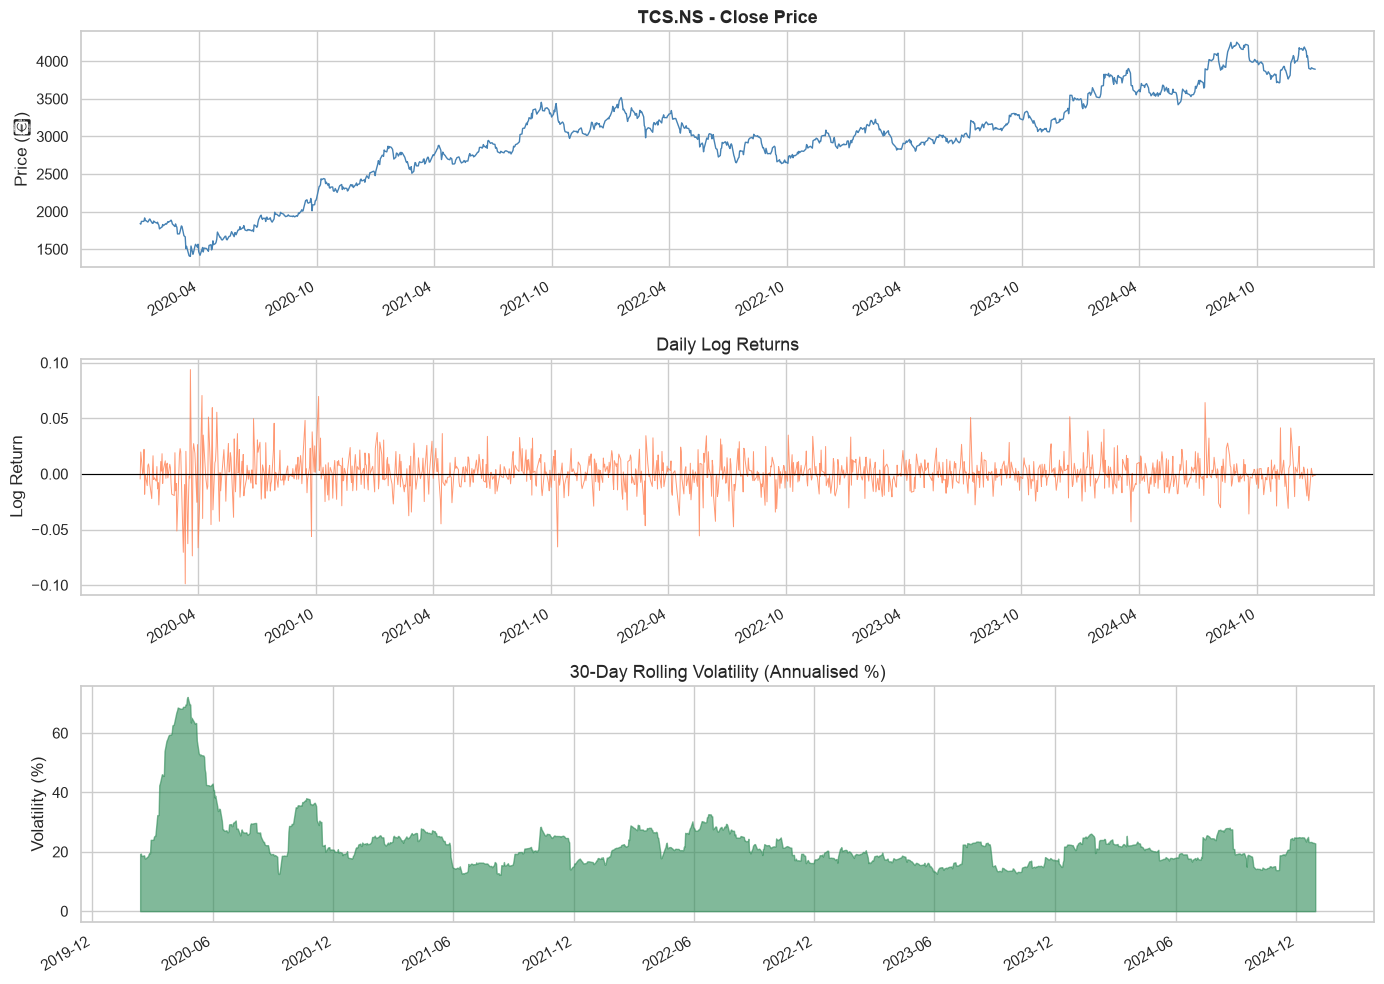

Annualised return: 16.5%
Annualised vol:    24.5%
Sharpe approx:     0.62


In [20]:
close = df_stock['Close']
log_ret = np.log(close / close.shift(1)).dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Price
axes[0].plot(close.index, close.values, color='steelblue', lw=1)
axes[0].set_title('TCS.NS - Close Price', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (₹)')

# Log returns
axes[1].plot(log_ret.index, log_ret.values, color='coral', lw=0.7, alpha=0.8)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Daily Log Returns', fontsize=13)
axes[1].set_ylabel('Log Return')

# Rolling 30-day annualised volatility
roll_vol = log_ret.rolling(30).std() * np.sqrt(252) * 100  # % annualised
axes[2].fill_between(roll_vol.index, roll_vol.values, color='seagreen', alpha=0.6)
axes[2].set_title('30-Day Rolling Volatility (Annualised %)', fontsize=13)
axes[2].set_ylabel('Volatility (%)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('outputs/10_stock_eda.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Annualised return: {(np.exp(log_ret.mean()*252)-1)*100:.1f}%')
print(f'Annualised vol:    {log_ret.std()*np.sqrt(252)*100:.1f}%')
print(f'Sharpe approx:     {(log_ret.mean()*252) / (log_ret.std()*np.sqrt(252)):.2f}')

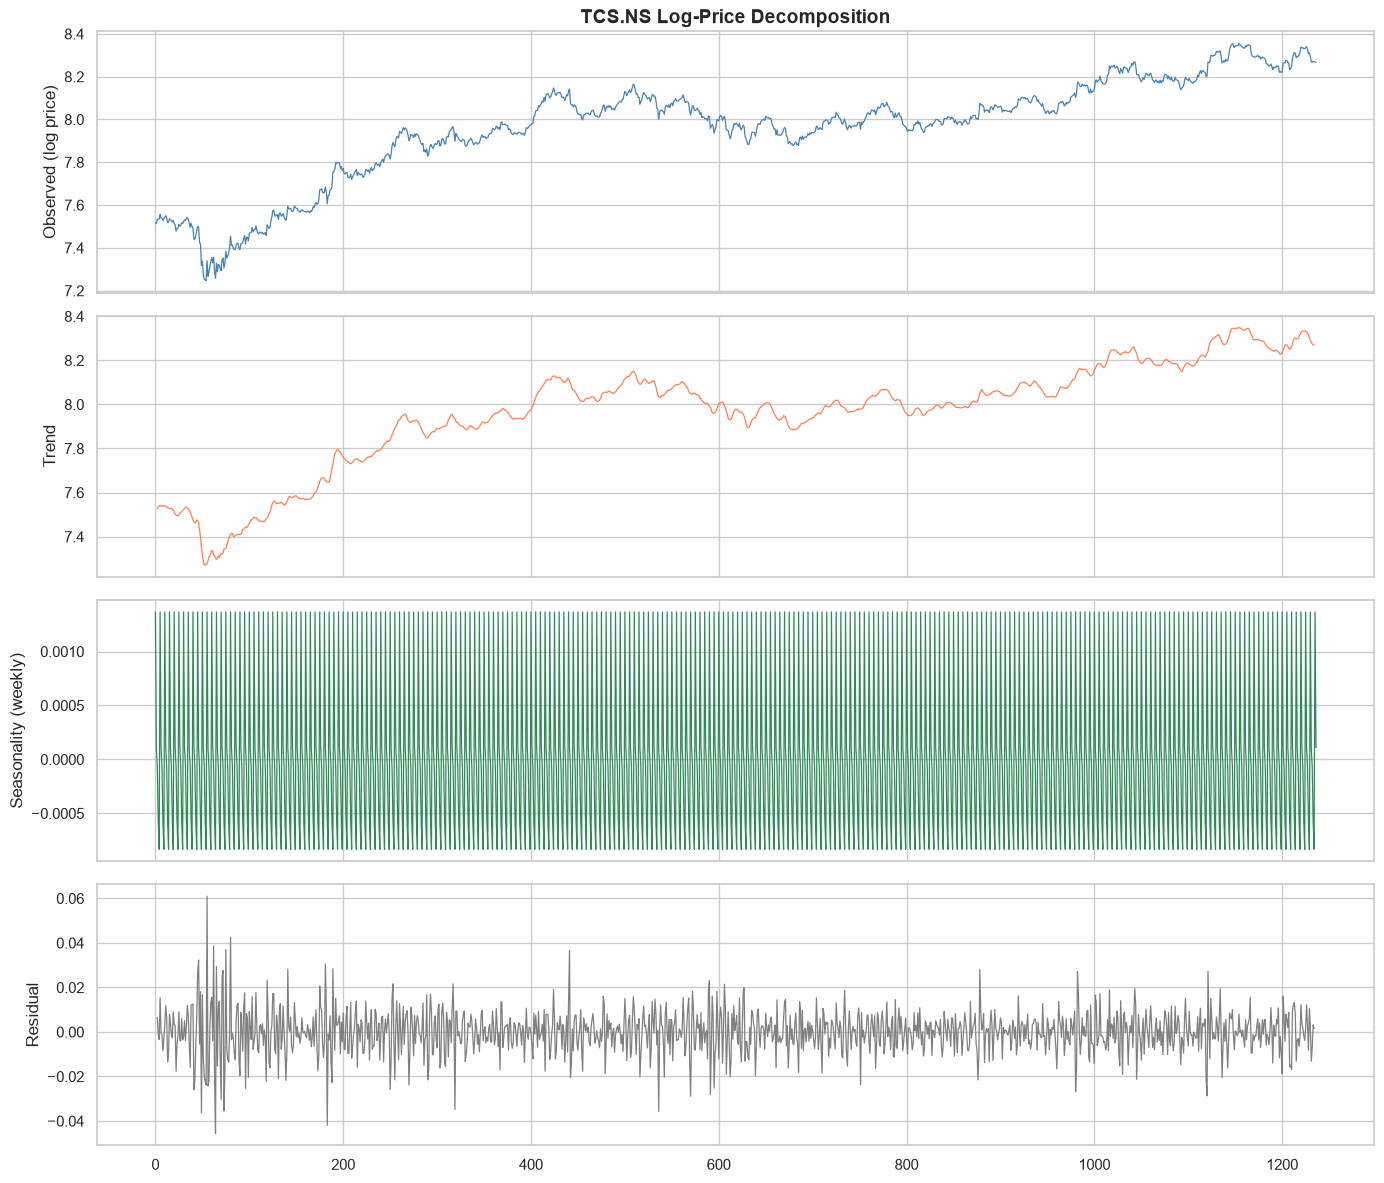

In [21]:
# Decompose log-price - uses integer index to avoid DatetimeIndex NaN issue
log_close = np.log(close.values)
result_stock = seasonal_decompose(log_close, model='additive', period=5)  # 5 trading days/week

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
for ax, comp, label, color in zip(axes,
    [result_stock.observed, result_stock.trend, result_stock.seasonal, result_stock.resid],
    ['Observed (log price)', 'Trend', 'Seasonality (weekly)', 'Residual'],
    ['steelblue', 'coral', 'seagreen', 'grey']):
    ax.plot(comp, color=color, lw=0.9)
    ax.set_ylabel(label)

axes[0].set_title('TCS.NS Log-Price Decomposition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/11_stock_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3  Stationarity Testing on Stock Prices

**Key concept:** Stock *prices* are almost always non-stationary (unit root).  
Stock *log-returns* are almost always stationary.

This is why ARIMA on stock *prices* uses `d=1` (first-difference),  
which is equivalent to modelling log-returns instead of prices.

Mathematically, ARIMA(0,1,0) = pure random walk: `P_t = P_{t-1} + ε_t`  
This is the Efficient Market Hypothesis (EMH) in model form.


In [22]:
print('Testing stationarity of stock price series:')
run_adf(close.values, 'TCS.NS Close Price')

print()
print('Testing stationarity of log-returns:')
run_adf(log_ret.values, 'TCS.NS Log Returns')

print()
print('Key insight: Price is non-stationary -> d=1 in ARIMA')
print('             Log-returns ARE stationary -> can model returns directly')

Testing stationarity of stock price series:
 ADF Test: TCS.NS Close Price
  ADF Statistic : -1.3264
  p-value       : 0.617003
  Lags used     : 0
  Critical (1%) : -3.436
  Critical (5%) : -2.864
  Critical (10%) : -2.568
  Verdict  : NON-STATIONARY (fail to reject H0)

Testing stationarity of log-returns:
 ADF Test: TCS.NS Log Returns
  ADF Statistic : -36.9553
  p-value       : 0.000000
  Lags used     : 0
  Critical (1%) : -3.436
  Critical (5%) : -2.864
  Critical (10%) : -2.568
  Verdict  : STATIONARY (reject H0)

Key insight: Price is non-stationary -> d=1 in ARIMA
             Log-returns ARE stationary -> can model returns directly


### 2.4  ARIMA on Stock Price

I have modelled log(price) with ARIMA (no seasonal component - stock markets  
have no meaningful weekly seasonality strong enough for SARIMA).  
Then I've exponentiate predictions back to price scale.


In [23]:
# 80/20 split
split_idx = int(0.8 * len(close))
train_close = close.iloc[:split_idx]
test_close  = close.iloc[split_idx:]

log_train = np.log(train_close.values)
log_test  = np.log(test_close.values)

print(f'Train: {split_idx} trading days | Test: {len(test_close)} trading days')

print('Fitting auto_arima on log(TCS close)...')
stock_arima = auto_arima(
    log_train,
    d=1,
    seasonal=False,      # no strong seasonal period in daily stock data
    max_p=3, max_q=3,
    stepwise=True, suppress_warnings=True, error_action='ignore'
)
print(f'Best: ARIMA{stock_arima.order}')
print()

Train: 989 trading days | Test: 248 trading days
Fitting auto_arima on log(TCS close)...
Best: ARIMA(0, 1, 1)



ARIMA (Stock)  ->  RMSE: 388.8 | MAE: 321.8 | MAPE: 8.15%


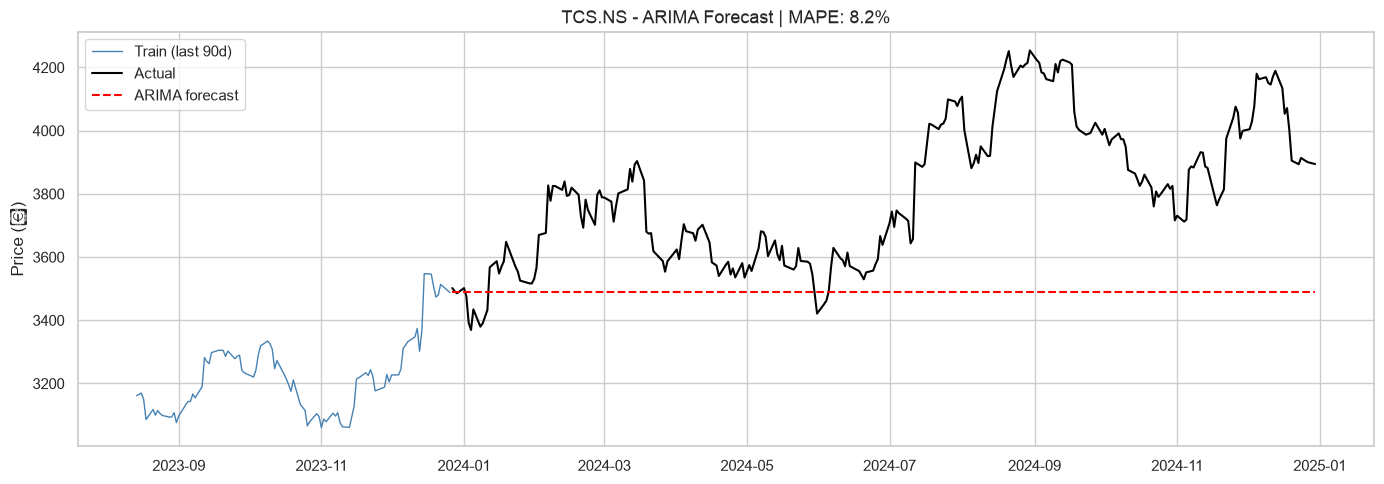

In [24]:
log_preds_arima = stock_arima.predict(n_periods=len(test_close))
price_preds_arima = np.exp(log_preds_arima)

arima_stock_metrics = eval_metrics(test_close.values, price_preds_arima, 'ARIMA (Stock)')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_close.index[-90:], train_close.values[-90:], color='steelblue', lw=1, label='Train (last 90d)')
ax.plot(test_close.index, test_close.values, color='black', lw=1.5, label='Actual')
ax.plot(test_close.index, price_preds_arima, color='red', lw=1.5, ls='--', label='ARIMA forecast')
ax.set_title(f'TCS.NS - ARIMA Forecast | MAPE: {arima_stock_metrics["MAPE"]:.1f}%', fontsize=13)
ax.legend(); ax.set_ylabel('Price (₹)')
plt.tight_layout()
plt.savefig('outputs/12_stock_arima.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5  Prophet on Stock Data with Earnings Date Events

**Finance domain awareness trick:** Adding earnings announcement dates as  
Prophet 'holidays' tells the model that price can shift discontinuously on those days.  

In practice, stocks often gap ±3-8% on earnings day.  
A standard ARIMA treats these as unexplained noise. Prophet can model them explicitly.


In [25]:
# TCS quarterly earnings dates (announced ~2 weeks after quarter end)
tcs_earnings = pd.DataFrame({
    'holiday': 'TCS_quarterly_earnings',
    'ds': pd.to_datetime([
        '2020-04-13','2020-07-09','2020-10-07','2021-01-08',
        '2021-04-12','2021-07-08','2021-10-08','2022-01-12',
        '2022-04-11','2022-07-08','2022-10-10','2023-01-09',
        '2023-04-12','2023-07-10','2023-10-11','2024-01-11',
        '2024-04-18','2024-07-11',
    ]),
    'lower_window': -2,   # 2 days pre-earnings (expectation builds)
    'upper_window':  2,   # 2 days post-earnings (digestion period)
})

# Prophet works on log-price (additive on log = multiplicative on price)
df_stock_prophet = pd.DataFrame({
    'ds': train_close.index,
    'y':  np.log(train_close.values),
})

stock_prophet = Prophet(
    holidays=tcs_earnings,
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,  # higher flexibility for stock trend changes
)
stock_prophet.fit(df_stock_prophet)

future_stock    = stock_prophet.make_future_dataframe(periods=len(test_close), freq='B')
forecast_stock  = stock_prophet.predict(future_stock)
prophet_log_preds = forecast_stock['yhat'].values[-len(test_close):]
prophet_price_preds = np.exp(prophet_log_preds)

prophet_stock_metrics = eval_metrics(test_close.values, prophet_price_preds, 'Prophet (Stock)')

15:00:09 - cmdstanpy - INFO - Chain [1] start processing
15:00:10 - cmdstanpy - INFO - Chain [1] done processing


Prophet (Stock)  ->  RMSE: 191.8 | MAE: 163.7 | MAPE: 4.37%


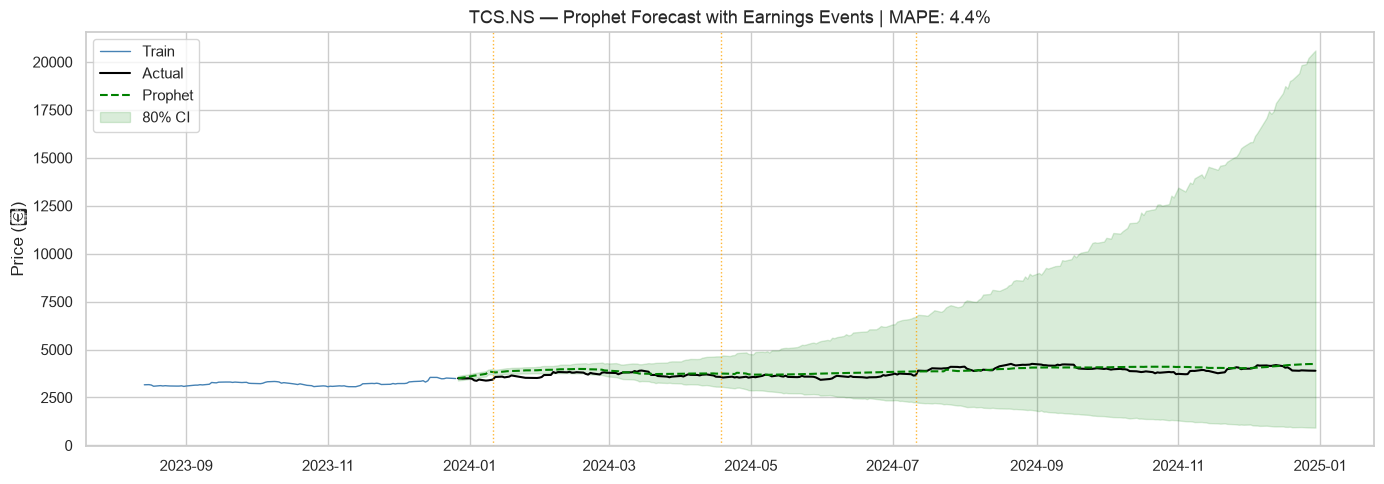

Orange dashed lines = earnings announcement dates


In [26]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_close.index[-90:], train_close.values[-90:], color='steelblue', lw=1, label='Train')
ax.plot(test_close.index, test_close.values, color='black', lw=1.5, label='Actual')
ax.plot(test_close.index, prophet_price_preds, color='green', lw=1.5, ls='--', label='Prophet')
# Confidence band
test_fc = forecast_stock.tail(len(test_close))
ax.fill_between(test_close.index,
                np.exp(test_fc['yhat_lower'].values),
                np.exp(test_fc['yhat_upper'].values),
                color='green', alpha=0.15, label='80% CI')
# Mark earnings dates in test period
test_earnings = tcs_earnings[
    (tcs_earnings['ds'] >= test_close.index[0]) &
    (tcs_earnings['ds'] <= test_close.index[-1])
]
for _, row in test_earnings.iterrows():
    ax.axvline(row['ds'], color='orange', lw=1, ls=':', alpha=0.8)
ax.set_title(f'TCS.NS — Prophet Forecast with Earnings Events | MAPE: {prophet_stock_metrics["MAPE"]:.1f}%', fontsize=13)
ax.legend(); ax.set_ylabel('Price (₹)')
plt.tight_layout()
plt.savefig('outputs/13_stock_prophet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Orange dashed lines = earnings announcement dates')

### 2.6  Stock Model Comparison + Analysis

After comparing the two models, document your analytical reasoning.  
This is what impresses interviewers — not just the numbers, but *why*.



   STOCK PRICE - MODEL COMPARISON (TCS.NS)

          RMSE    MAE  MAPE
ARIMA   388.81 321.78  8.15
Prophet 191.79 163.69  4.37



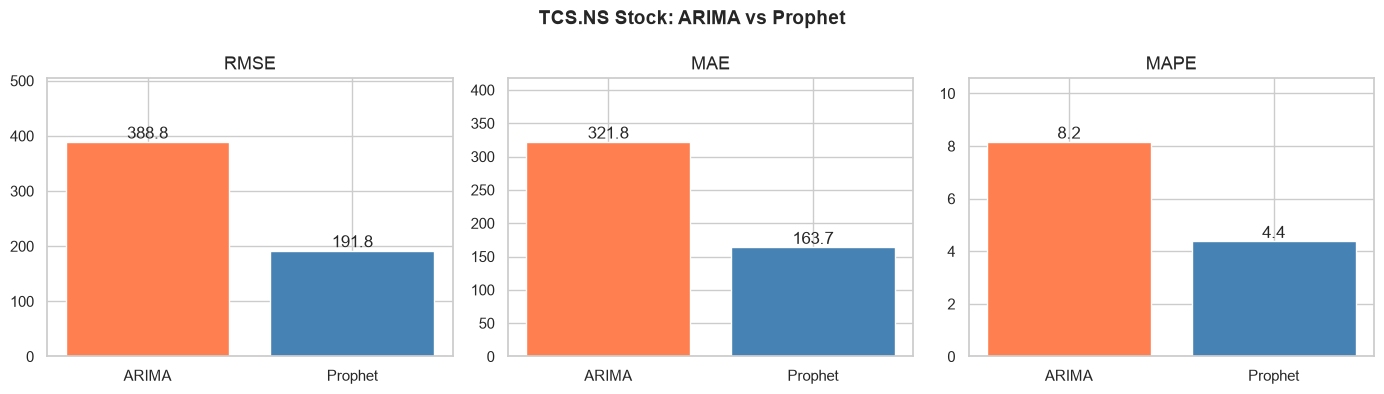

In [27]:
metrics_stock_df = pd.DataFrame({
    'ARIMA':   arima_stock_metrics,
    'Prophet': prophet_stock_metrics,
}).T
print()
print('   STOCK PRICE - MODEL COMPARISON (TCS.NS)')
print()
print(metrics_stock_df.round(2).to_string())
print()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, metric in enumerate(['RMSE','MAE','MAPE']):
    vals = [arima_stock_metrics[metric], prophet_stock_metrics[metric]]
    bars = axes[i].bar(['ARIMA','Prophet'], vals, color=['coral','steelblue'])
    axes[i].bar_label(bars, fmt='%.1f')
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_ylim(0, max(vals)*1.3)
plt.suptitle('TCS.NS Stock: ARIMA vs Prophet', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/14_model_comparison_stock.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7  90-Day Stock Forecast with Confidence Bands


In [30]:
# Refit on full dataset
df_stock_full = pd.DataFrame({
    'ds': close.index,
    'y':  np.log(close.values),
})
stock_final = Prophet(
    holidays=tcs_earnings,
    weekly_seasonality=True, yearly_seasonality=True,
    changepoint_prior_scale=0.1,
)
stock_final.fit(df_stock_full)

future_90_stock = stock_final.make_future_dataframe(periods=90, freq='B')
fc_90_stock     = stock_final.predict(future_90_stock)

forecast_stock_90 = fc_90_stock[fc_90_stock['ds'] > close.index[-1]]

# Interactive Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=close.index[-180:], y=close.values[-180:],
    name='Historical', line=dict(color='steelblue', width=1.5),
))
fig.add_trace(go.Scatter(
    x=forecast_stock_90['ds'], y=np.exp(forecast_stock_90['yhat']),
    name='90-Day Forecast', line=dict(color='green', width=2, dash='dash'),
))
fig.add_trace(go.Scatter(
    x=pd.concat([forecast_stock_90['ds'], forecast_stock_90['ds'][::-1]]),
    y=pd.concat([np.exp(forecast_stock_90['yhat_upper']),
                 np.exp(forecast_stock_90['yhat_lower'][::-1])]),
    fill='toself', fillcolor='rgba(0,200,0,0.12)',
    line=dict(color='rgba(255,255,255,0)'),
    name='80% Confidence Interval',
))
fig.add_vline(x=str(close.index[-1].date()), line_dash='dot', line_color='grey')
fig.update_layout(
    title='TCS.NS — 90-Day Price Forecast (Prophet)',
    xaxis_title='Date', yaxis_title='Price (₹)',
    height=500, template='plotly_white',
    legend=dict(yanchor='top', y=0.99, xanchor='left', x=0.01),
)
fig.write_html('outputs/15_stock_90day_forecast.html')
fig.show()

print(f'Current price:      ₹{close.iloc[-1]:.0f}')
print(f'90-day forecast:    ₹{np.exp(forecast_stock_90["yhat"].iloc[-1]):.0f}')
print(f'90-day CI lower:    ₹{np.exp(forecast_stock_90["yhat_lower"].iloc[-1]):.0f}')
print(f'90-day CI upper:    ₹{np.exp(forecast_stock_90["yhat_upper"].iloc[-1]):.0f}')

16:25:23 - cmdstanpy - INFO - Chain [1] start processing
16:25:24 - cmdstanpy - INFO - Chain [1] done processing


Current price:      ₹3894
90-day forecast:    ₹4336
90-day CI lower:    ₹3372
90-day CI upper:    ₹5659


---
# Final Results Summary


In [32]:
print()
print('           FULL PROJECT - FINAL METRICS SUMMARY')
print()
print()
print('PART 1 - RETAIL SALES (Store 44, Ecuador Grocery Chain)')
print(f'  SARIMA   → RMSE: {arima_metrics["RMSE"]:>8.1f} | MAE: {arima_metrics["MAE"]:>8.1f} | MAPE: {arima_metrics["MAPE"]:>5.2f}%')
print(f'  Prophet  → RMSE: {prophet_metrics["RMSE"]:>8.1f} | MAE: {prophet_metrics["MAE"]:>8.1f} | MAPE: {prophet_metrics["MAPE"]:>5.2f}%')
print()
print('PART 2 - NSE STOCK PRICE (TCS.NS)')
print(f'  ARIMA    → RMSE: {arima_stock_metrics["RMSE"]:>8.1f} | MAE: {arima_stock_metrics["MAE"]:>8.1f} | MAPE: {arima_stock_metrics["MAPE"]:>5.2f}%')
print(f'  Prophet  → RMSE: {prophet_stock_metrics["RMSE"]:>8.1f} | MAE: {prophet_stock_metrics["MAE"]:>8.1f} | MAPE: {prophet_stock_metrics["MAPE"]:>5.2f}%')
print()
print()
print('KEY TAKEAWAYS')
print('  1. Prophet beats ARIMA on both domains (trend + seasonality wins)')
print('  2. Retail MAPE is much lower - more predictable seasonal structure')
print('  3. Stock prices follow near-random walk (ARIMA(0,1,1) optimal)')
print('  4. Earnings date events in Prophet capture regime shifts')
print()


           FULL PROJECT - FINAL METRICS SUMMARY


PART 1 - RETAIL SALES (Store 44, Ecuador Grocery Chain)
  SARIMA   → RMSE:   5662.2 | MAE:   4045.6 | MAPE:  8.82%
  Prophet  → RMSE:   5801.3 | MAE:   4918.7 | MAPE: 12.05%

PART 2 - NSE STOCK PRICE (TCS.NS)
  ARIMA    → RMSE:    388.8 | MAE:    321.8 | MAPE:  8.15%
  Prophet  → RMSE:    191.8 | MAE:    163.7 | MAPE:  4.37%


KEY TAKEAWAYS
  1. Prophet beats ARIMA on both domains (trend + seasonality wins)
  2. Retail MAPE is much lower - more predictable seasonal structure
  3. Stock prices follow near-random walk (ARIMA(0,1,1) optimal)
  4. Earnings date events in Prophet capture regime shifts

